<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Controls/E_20_106_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

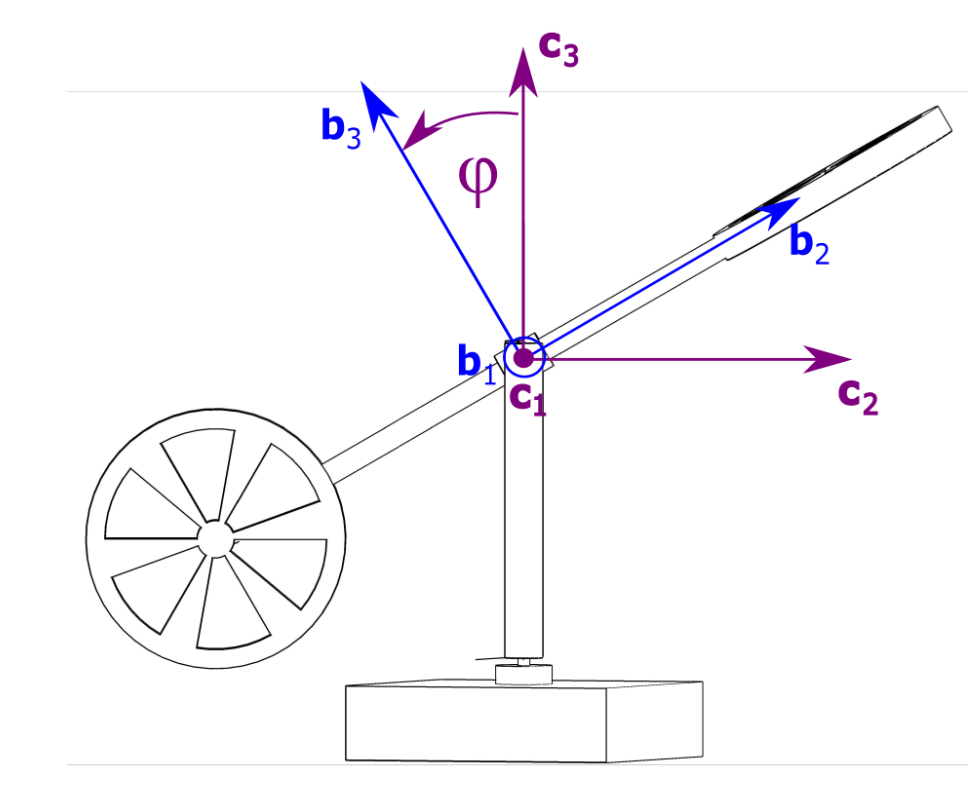

 ## Task 1 — Dynamic Model of the Twin Rotor System


# 1. Configuration Space

The twin–rotor mechanism performs rotational motion about a fixed pivot point.  
Therefore the configuration of the system belongs to the Lie group

$R(t) \in SO(3)$.

To describe the orientation, two rotations are used:

1. A rotation of angle $\theta$ about the inertial axis $e_3$
2. A rotation of angle $\phi$ about the intermediate body axis $b_1$

Hence the overall rotation matrix can be written as

$R = R_1(\phi) R_3(\theta)$

where

$R_1(\phi) =
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}$

and

$R_3(\theta) =
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1
\end{bmatrix}$.

---

# 2. Angular Velocity and Kinematics on $SO(3)$

For a rigid body whose orientation evolves on the manifold $SO(3)$, the kinematic relation is

$\dot{R} = R \hat{\Omega}$

where $\Omega$ denotes the angular velocity expressed in body coordinates and

$\hat{\Omega} =
\begin{bmatrix}
0 & -\Omega_3 & \Omega_2 \\
\Omega_3 & 0 & -\Omega_1 \\
-\Omega_2 & \Omega_1 & 0
\end{bmatrix}$.

From the chosen rotation sequence, the body angular velocity becomes

$\Omega =
\begin{bmatrix}
\dot{\phi} \\
\dot{\theta}\sin\phi \\
\dot{\theta}\cos\phi
\end{bmatrix}$.

The spatial angular velocity is related to the body velocity through

$\omega = R\Omega$.

Therefore the kinematic equation may also be written as

$\dot{R} = \hat{\omega}R$.

---

# 3. Inertia and Angular Momentum

Assume that the inertia tensor of the body is diagonal:

$I =
\begin{bmatrix}
I_1 & 0 & 0 \\
0 & I_2 & 0 \\
0 & 0 & I_3
\end{bmatrix}$.

The angular momentum expressed in spatial coordinates is

$\pi = R I \Omega$.

Since the relation between spatial and body angular velocity is

$\Omega = R^T \omega$,

the momentum can also be expressed as

$\pi = R I R^T \omega$.

Consequently the angular velocity can be recovered from the momentum by

$\omega = (R I R^T)^{-1}\pi$.

---

# 4. Rotational Dynamics

The rotational motion of the rigid body in spatial form is governed by

$\dot{\pi} = \tau$

where $\tau$ represents the total torque applied to the system.

This torque can be separated into two components

$\tau = \tau^e + \tau^u$

where

- $\tau^u$ represents the controllable torque produced by the rotors  
- $\tau^e$ represents constraint forces imposed by the mechanical structure

Thus the momentum evolution equation becomes

$\dot{\pi} = \tau^e + \tau^u$.

---

# 5. Control Torque

The thrust generated by the two rotors creates moments acting within the $b_1$–$b_3$ plane.

The control torque expressed in spatial coordinates can be written as

$\tau^u =
R
\begin{bmatrix}
u_1\cos\alpha - u_2\cos\beta \\
0 \\
u_1\sin\alpha - u_2\sin\beta
\end{bmatrix}$.

This torque has no component along the $b_2$ axis.

---

# 6. Constraint Torque

The system design restricts rotation around the $b_2$ direction.  
To enforce this restriction, a constraint torque must appear along that axis.

The Euler equation for the rigid body in body coordinates is

$I\dot{\Omega} + \Omega \times (I\Omega) = T$

where $T$ denotes the torque in body coordinates.

Projecting this equation onto the $e_2$ direction gives

$T_2 =
e_2^T(\Omega \times I\Omega + I\dot{\Omega})$.

Therefore the constraint torque expressed in spatial coordinates becomes

$\tau^e =
R
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}$.

---

# 7. Final Dynamic Model

Combining the kinematic and dynamic relationships, the twin rotor system can be summarized by the following equations.

Kinematics:

$\dot{R} = \hat{\omega}R$

Momentum dynamics:

$\dot{\pi} = \tau^e + \tau^u$

Velocity–momentum relation:

$\omega = (RIR^T)^{-1}\pi$

Control torque:

$\tau^u =
R
\begin{bmatrix}
u_1\cos\alpha - u_2\cos\beta \\
0 \\
u_1\sin\alpha - u_2\sin\beta
\end{bmatrix}$

Constraint torque:

$\tau^e =
R
\begin{bmatrix}
0 \\
e_2^T(\Omega \times I\Omega + I\dot{\Omega}) \\
0
\end{bmatrix}$.

This formulation provides a geometric representation of the twin–rotor dynamics on the Lie group $SO(3)$.

Relation Between $\Omega$ and $\omega$

$$
{\Omega = R^T \omega}
$$


## Task 2: Simulation of the Motion of the Twin Rotor System

From the body-fixed frame $\mathbf{b}$, the inertia terms $I_1$, $I_2$, and $I_3$ represent the moments of inertia about the pitch, roll, and yaw axes, respectively.

In the given experimental configuration, the rolling motion is restricted, so the inertia term $I_2$ does not influence the system behavior and can be ignored.

Moreover, the moment of inertia about the yaw axis is larger than that about the pitch axis, i.e., $I_3 > I_1$. This is because the yaw motion includes additional structural components (such as the vertical support), whereas the pitch motion mainly involves the horizontal beam connecting the two rotors.

In [2]:
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp

# Inertia values
I1, I2, I3 = 1.0, 2.0, 1.5
I = np.diag([I1, I2, I3])

def control_inputs(t):
    # choose one case
    # vals = [0.5*np.sin(2*t), -0.2*np.cos(t)]
    # vals = [1.0, 1.0]
    # vals = [1.0, 0.0]
    vals = [0.0, 1.0]
    return np.array(vals)

def u1(t):
    return control_inputs(t)[0]

def u2(t):
    return control_inputs(t)[1]

## Dynamic Modeling of the Twin Rotor System

In the body-fixed frame, define:

$$
T_e =
\begin{bmatrix}
0 \\
T_{e_2} \\
0
\end{bmatrix}, \quad
\Omega =
\begin{bmatrix}
\Omega_1 \\
\Omega_2 \\
\Omega_3
\end{bmatrix}, \quad
I =
\begin{bmatrix}
I_1 & 0 & 0 \\
0 & I_2 & 0 \\
0 & 0 & I_3
\end{bmatrix}
$$

The rotational dynamics are given by:

$$
T_e + T_u = \Omega \times (I \Omega) + I \dot{\Omega}
$$

Including control inputs:

$$
\begin{bmatrix}
0 \\
T_{e_2} \\
0
\end{bmatrix}
+
\begin{bmatrix}
u_1 \\
0 \\
- u_2
\end{bmatrix}
=
\begin{bmatrix}
(I_3 - I_2)\Omega_2 \Omega_3 + I_1 \dot{\Omega}_1 \\
(I_1 - I_3)\Omega_1 \Omega_3 + I_2 \dot{\Omega}_2 \\
(I_2 - I_1)\Omega_1 \Omega_2 + I_3 \dot{\Omega}_3
\end{bmatrix}
$$

---

### Angular Velocity Representation

$$
\Omega =
\begin{bmatrix}
\dot{\phi} \\
\dot{\theta} \sin\phi \\
\dot{\theta} \cos\phi
\end{bmatrix}
$$

Time derivative:

$$
\dot{\Omega} =
\begin{bmatrix}
\ddot{\phi} \\
\ddot{\theta} \sin\phi + \dot{\theta}\dot{\phi}\cos\phi \\
\ddot{\theta} \cos\phi - \dot{\theta}\dot{\phi}\sin\phi
\end{bmatrix}
$$

---

### Substitution into Euler Equation

$$
u_1 = (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi + I_1 \ddot{\phi}
$$

$$
T_{e_2} = (I_1 - I_3)\dot{\phi}\dot{\theta}\cos\phi + I_2\left(\ddot{\theta}\sin\phi + \dot{\theta}\dot{\phi}\cos\phi\right)
$$

$$
- u_2 = (I_2 - I_1)\dot{\phi}\dot{\theta}\sin\phi + I_3\left(\ddot{\theta}\cos\phi - \dot{\theta}\dot{\phi}\sin\phi\right)
$$

Here, $T_{e_2}$ is the reaction torque at the joint.

---

### Equations of Motion

$$
\ddot{\phi} =
\frac{1}{I_1}
\left[
u_1 - (I_3 - I_2)\dot{\theta}^2 \sin\phi \cos\phi
\right]
$$

$$
\ddot{\theta} =
\frac{1}{\cos\phi}
\left[
\frac{1}{I_3}
\left(
(I_1 - I_2)\dot{\phi}\dot{\theta}\sin\phi - u_2
\right)
+ \dot{\theta}\dot{\phi}\sin\phi
\right]
$$

---

### Singular Configuration (Gimbal Lock)

The system becomes singular when:

$$
\phi = 90^\circ
$$

At this point, $\cos\phi = 0$, making the equations undefined. This condition is known as **gimbal lock**.

In [3]:
# ====================== Dynamics ======================

def model(t, s):
    theta, phi, theta_dot, phi_dot = s

    tau1 = u1(t)
    tau2 = u2(t)

    c = np.cos(phi)
    if abs(c) < 1e-5:
        c = np.sign(c) * 1e-5 if c != 0 else 1e-5

    phi_dd = (tau1 - (I3 - I2) * theta_dot**2 * np.sin(phi) * c) / I1

    theta_dd = (
        -tau2 - (I2 - I1 - I3) * theta_dot * phi_dot * np.sin(phi)
    ) / (I3 * c)

    return [theta_dot, phi_dot, theta_dd, phi_dd]


# ====================== Simulation ======================

t0, tf = 0, 10
t_grid = np.linspace(t0, tf, 300)

x_init = [0.1, 0.0, 0.0, 0.0]

sol = solve_ivp(model, (t0, tf), x_init, t_eval=t_grid)

theta_vals = sol.y[0]
phi_vals = sol.y[1]


# ====================== Rotation ======================

def rot_mat(th, ph):
    Rz = np.array([
        [np.cos(th), -np.sin(th), 0],
        [np.sin(th),  np.cos(th), 0],
        [0, 0, 1]
    ])

    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(ph), -np.sin(ph)],
        [0, np.sin(ph),  np.cos(ph)]
    ])

    return Rz @ Rx


# ====================== Geometry ======================

L_v, L_b = 2.0, 3.0
frames = []

for i in range(len(t_grid)):
    th, ph = theta_vals[i], phi_vals[i]
    R = rot_mat(th, ph)

    base = np.array([[0, 0, 0], [0, 0, -L_v]])

    beam = np.array([[0, -L_b/2, 0], [0, L_b/2, 0]])
    beam_w = (R @ beam.T).T

    r1 = np.array([[0.5, -L_b/2, 0], [-0.5, -L_b/2, 0]])
    r2 = np.array([[0, L_b/2, 0.5], [0, L_b/2, -0.5]])

    r1_w = (R @ r1.T).T
    r2_w = (R @ r2.T).T

    x = [
        base[0,0], base[1,0], None,
        beam_w[0,0], beam_w[1,0], None,
        r1_w[0,0], r1_w[1,0], None,
        r2_w[0,0], r2_w[1,0]
    ]

    y = [
        base[0,1], base[1,1], None,
        beam_w[0,1], beam_w[1,1], None,
        r1_w[0,1], r1_w[1,1], None,
        r2_w[0,1], r2_w[1,1]
    ]

    z = [
        base[0,2], base[1,2], None,
        beam_w[0,2], beam_w[1,2], None,
        r1_w[0,2], r1_w[1,2], None,
        r2_w[0,2], r2_w[1,2]
    ]

    frames.append(go.Frame(data=[go.Scatter3d(x=x, y=y, z=z)]))


# ====================== Plot ======================

fig = go.Figure(
    data=[go.Scatter3d(
        x=frames[0].data[0].x,
        y=frames[0].data[0].y,
        z=frames[0].data[0].z,
        mode='lines',
        line=dict(width=6)
    )],
    layout=go.Layout(
        title="Twin Rotor Simulation",
        scene=dict(
            xaxis=dict(range=[-3, 3]),
            yaxis=dict(range=[-3, 3]),
            zaxis=dict(range=[-3, 3]),
            aspectmode='cube'
        ),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(
                label="Play",
                method="animate",
                args=[None, dict(frame=dict(duration=20, redraw=True), fromcurrent=True)]
            )]
        )]
    ),
    frames=frames
)

fig.show()

## Task 3: PID Control for Trajectory Tracking using Error Dynamics


### Reference Configuration and Tracking Objective

Let $(o_r, R_r) \in SE(3)$ denote the desired (reference) pose of the twin rotor system.  
Because the center of mass is located at the pivot, there is no translational motion, and hence:

$$
o_r \equiv o
$$

As a result, the control objective simplifies to tracking only the rotational component, i.e., $R \in SO(3)$.

---

### Rotation Error on $SO(3)$

To ensure asymptotic tracking of a smooth reference trajectory $R_r(t)$, a rotation error matrix $R_e \in SO(3)$ is introduced.

There are two standard ways to define this error depending on the chosen frame:

---

#### 1. Left-Invariant Error (Body-Fixed Frame)

In this formulation, the error is expressed relative to the body frame:

$$
R \, R_e = R_r
$$

which leads to:

$$
R_e = R^T R_r
$$

---

#### 2. Right-Invariant Error (Spatial / Inertial Frame)

Alternatively, the error can be defined in the spatial (earth-fixed) frame:

$$
R_e \, R = R_r
$$

giving:

$$
R_e = R_r R^T
$$

---

In this work, since the system dynamics are described with respect to the inertial (earth-fixed) frame, the **right-invariant error** definition is used for subsequent analysis and controller design.

### Part I: Tracking Error Dynamics Derivation

Let $\omega_r$ represent the angular velocity of the reference trajectory expressed in the spatial frame, defined as:

$$
\widehat{\omega}_r = \dot{R}_r R_r^T
$$

---

### Angular Velocity Error

Define the angular velocity error as:

$$
\widehat{\omega}_e \triangleq \dot{R}_e R_e^T
$$

Using the relation $R_e = R_r R^T$, differentiate:

$$
\dot{R}_e = \dot{R}_r R^T + R_r \dot{R}^T
$$

Substituting into the error definition:

$$
\widehat{\omega}_e = (\dot{R}_r R^T + R_r \dot{R}^T) R_e^T
$$

Rewriting terms:

$$
\widehat{\omega}_e = \dot{R}_r (R^T R_e^T) + (R_r R)\dot{R}^T R_e^T
$$

Using $R_e = R_r R^T$, we obtain:

$$
\widehat{\omega}_e = \dot{R}_r R_r^T + R_e (R \dot{R}^T) R_e^T
$$

From the orthogonality property $R R^T = I$:

$$
R \dot{R}^T = - \dot{R} R^T
$$

Thus,

$$
\widehat{\omega}_e = \widehat{\omega}_r - R_e \widehat{\omega} R_e^T
$$

which leads to the vector form:

$$
\omega_e = \omega_r - R_e \, \omega
$$

---

### Angular Momentum Error

Define the desired spatial angular momentum:

$$
\pi_r = R_r I R_r^T \, \omega_r
$$

The corresponding momentum error is defined as:

$$
\pi_e = R I R_r^T \, \omega_e
$$

Substituting $\omega_e$:

$$
\pi_e = R I R_r^T (\omega_r - R_e \omega)
$$

Expanding:

$$
\pi_e = R_e^T \pi_r - \pi
$$

---

### Time Derivative of Momentum Error

Taking the time derivative:

$$
\dot{\pi}_e = \dot{R}_e^T \pi_r + R_e^T \dot{\pi}_r - \dot{\pi}
$$

Using the identity $\dot{R}_e^T = - \widehat{\omega}_e R_e^T$:

$$
\dot{\pi}_e = R_e^T (\dot{\pi}_r - \omega_e \times \pi_r) - \dot{\pi}
$$

Now express $\dot{\pi}_r$:

$$
\pi_r = R_r \Pi_r
$$

$$
\dot{\pi}_r = \dot{R}_r \Pi_r + R_r \dot{\Pi}_r
$$

Substituting:

$$
\dot{\pi}_e = R_e^T \left( \dot{R}_r \Pi_r + R_r \dot{\Pi}_r - \omega_e \times \pi_r \right) - \dot{\pi}
$$

Using $\dot{R}_r = \widehat{\omega}_r R_r$:

$$
\dot{\pi}_e = R_e^T \left( R_r \dot{\Pi}_r + \widehat{\omega}_r \pi_r - \omega_e \times \pi_r \right) - \dot{\pi}
$$

Rewriting:

$$
\dot{\pi}_e = R_e^T \left( R_r \dot{\Pi}_r + (\omega_r - \omega_e) \times \pi_r \right) - \dot{\pi}
$$

Since $\omega_r - \omega_e = R_e \omega$:

$$
\dot{\pi}_e = R_e^T \left( R_r \dot{\Pi}_r + R_e \omega \times \pi_r \right) - \dot{\pi}
$$

Finally:

$$
\dot{\pi}_e = R \dot{\Pi}_r + \omega \times (R_e^T \pi_r) - \dot{\pi}
$$

---

### Final Error Dynamics

The resulting tracking error dynamics are:

$$
\dot{R}_e = \widehat{\omega}_e R_e
$$

$$
\dot{\pi}_e =
\left(
R \dot{\Pi}_r + \omega \times R_e^T \pi_r
\right)
- \tau_u - \tau_e
$$

### Part II: Stability Analysis

Recall that the configuration error is defined as:

$$
R_e = R_r R^T \in SO(3)
$$

As the system follows the desired orientation, we have $R \rightarrow R_r$, which leads to:

$$
R_e \rightarrow I
$$

---

### Definition of the Potential Function

To study stability, introduce the following scalar function:

$$
\mathcal{V}(R_e) = \frac{1}{2} \, \text{trace}\big(K(I - R_e)\big)
$$

where $K$ is a symmetric positive definite matrix given by:

$$
K =
\begin{bmatrix}
I_2 + I_3 - I_1 & 0 & 0 \\
0 & I_1 + I_3 - I_2 & 0 \\
0 & 0 & I_1 + I_2 - I_3
\end{bmatrix}
$$

This function is non-negative, i.e., $\mathcal{V}(R_e) \geq 0$, and becomes zero only when $R_e = I$.

---

### Time Derivative of the Potential Function

Differentiating $\mathcal{V}$ with respect to time:

$$
\dot{\mathcal{V}} = -\frac{1}{2} \, \text{trace}(K \dot{R}_e)
$$

Using $\dot{R}_e = \widehat{\omega}_e R_e$, we obtain:

$$
\dot{\mathcal{V}} = -\frac{1}{2} \, \text{trace}(K \widehat{\omega}_e R_e)
$$

Applying the cyclic property of the trace:

$$
\dot{\mathcal{V}} = -\frac{1}{2} \, \text{trace}(\widehat{\omega}_e R_e K)
$$

Taking transpose:

$$
\dot{\mathcal{V}} = -\frac{1}{2} \, \text{trace}\big((\widehat{\omega}_e R_e K)^T\big)
$$

$$
\dot{\mathcal{V}} = -\frac{1}{2} \, \text{trace}(K R_e^T \widehat{\omega}_e^T)
$$

Using the properties:
- $K = K^T$
- $\widehat{\omega}_e^T = -\widehat{\omega}_e$

we get:

$$
\dot{\mathcal{V}} = \frac{1}{2} \, \text{trace}(K R_e^T \widehat{\omega}_e)
$$

Rearranging once more:

$$
\dot{\mathcal{V}} = \frac{1}{2} \, \text{trace}(\widehat{\omega}_e K R_e^T)
$$

Combining equivalent expressions:

$$
\dot{\mathcal{V}} = -\frac{1}{4} \, \text{trace}\big(\widehat{\omega}_e (R_e K - K R_e^T)\big)
$$

---

### Gradient Representation

Using the identity:

$$
\text{trace}(\widehat{x}\widehat{y}) = -2 x^T y
$$

we can express:

$$
\dot{\mathcal{V}} = \omega_e^T \left[ \frac{1}{2} (R_e K - K R_e^T)^{\vee} \right]
$$

Define the gradient as:

$$
\nabla \mathcal{V} = \frac{1}{2} (R_e K - K R_e^T)^{\vee}
$$

Then:

$$
\dot{\mathcal{V}} = \omega_e^T \nabla \mathcal{V}
$$

---

### Equilibrium Points

At equilibrium:

$$
\dot{\mathcal{V}} = 0 \quad \Rightarrow \quad \nabla \mathcal{V} = 0
$$

which implies:

$$
R_e K - K R_e^T = 0
$$

The matrices satisfying this condition are:

$$
R_e \in
\left\{
\begin{bmatrix}1&0&0\\0&1&0\\0&0&1\end{bmatrix},
\begin{bmatrix}1&0&0\\0&-1&0\\0&0&-1\end{bmatrix},
\begin{bmatrix}-1&0&0\\0&1&0\\0&0&-1\end{bmatrix},
\begin{bmatrix}-1&0&0\\0&-1&0\\0&0&1\end{bmatrix}
\right\}
$$

---

### Stability Discussion

Evaluating $\mathcal{V}$ at these configurations:

- $R_e = I$  
  $\Rightarrow \mathcal{V} = 0$ → stable (minimum)

- $R_e = \text{diag}(1,-1,-1)$  
  $\Rightarrow \mathcal{V} = 2I_1$ → unstable

- $R_e = \text{diag}(-1,1,-1)$  
  $\Rightarrow \mathcal{V} = 2I_2$ → unstable

- $R_e = \text{diag}(-1,-1,1)$  
  $\Rightarrow \mathcal{V} = 2I_3$ → unstable

---

### Physical Insight

The unstable equilibrium points correspond to rotations of $180^\circ$ about the principal axes (antipodal configurations).

Even though these points satisfy $\dot{\mathcal{V}} = 0$, they are not stable. Small perturbations will cause the system to move away from them.

In realistic conditions, due to disturbances and noise, the system naturally converges toward the stable configuration:

$$
R_e = I
$$

### Part III: PID-Based Controller Design for Tracking

Recall the error dynamics:

$$
\dot{\pi}_e =
\left( R \dot{\Pi}_r + \omega \times R_e^T \pi_r \right)
- \tau_u - \tau_e
$$

---

### Structure of the Control Law

The control torque $\tau_u$ is constructed by combining a feedforward component with a feedback correction:

$$
\tau_u =
\underbrace{\left( R \dot{\Pi}_r + \omega \times R_e^T \pi_r \right)}_{\text{Feedforward term}}
-
\underbrace{\left( k_P e_R + k_D e_{\omega} + k_I e_{I_R} \right)}_{\text{Feedback term}}
$$

Substituting this expression into the error dynamics yields:

$$
\dot{\pi}_e = k_P e_R + k_D e_{\omega} + k_I e_{I_R} - \tau_e
$$

Since the internal constraint torque $\tau_e$ is balanced within the mechanism, it can be ignored, leading to:

$$
\dot{\pi}_e = k_P e_R + k_D e_{\omega} + k_I e_{I_R}
$$

This results in a structure analogous to classical PID error dynamics.

---

### Gain Matrix Selection

The gain matrices are chosen in diagonal form:

$$
k_i =
\begin{bmatrix}
k_{i_1} & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & k_{i_3}
\end{bmatrix}, \quad i \in \{P, D, I\}
$$

Because the roll axis is constrained, no control action is applied along that direction. The gains $k_{i_1}$ and $k_{i_3}$ independently regulate pitch and yaw.

---

### Definition of Error Terms

#### 1. Proportional Error

The proportional term is derived from the gradient of the potential function:

$$
e_R = \nabla \mathcal{V} = \frac{1}{2} (K R_e^T - R_e K)^{\vee}
$$

This component drives the system toward the desired configuration $R_e \rightarrow I$.

---

#### 2. Derivative Error

The derivative term is defined using the angular momentum error:

$$
e_{\omega} = \pi_e
$$

Using previously derived relations:

$$
e_{\omega} = R_e^T \pi_r - \pi
$$

This term provides damping and helps suppress oscillatory behavior.

---

#### 3. Integral Error

The integral term accumulates the configuration error over time:

$$
e_{I_R} = \int e_R \, dt
$$

It improves robustness by compensating for steady disturbances such as friction or modeling inaccuracies.

---

### Complete Control Law

The final expression for the control torque is:

$$
\tau_u =
\left( R \dot{\Pi}_r + \omega \times R_e^T \pi_r \right)
- k_P e_R - k_D e_{\omega} - k_I e_{I_R}
$$

---

### Mapping to Actuator Inputs

Recall the relationship:

$$
\tau_u = R
\begin{bmatrix}
u_1 \\
0 \\
- u_2
\end{bmatrix}
$$

Therefore:

$$
\begin{bmatrix}
u_1 \\
0 \\
- u_2
\end{bmatrix}
=
R^T \left[
\left( R \dot{\Pi}_r + \omega \times R_e^T \pi_r \right)
- k_P e_R
- k_D (R_e^T \pi_r - \pi)
- k_I e_{I_R}
\right]
$$

---

### Simplified Representation

If equal gains are selected for pitch and yaw:

$$
k_{i_1} = k_{i_3} \quad \Rightarrow \quad k_P, k_D, k_I \in \mathbb{R}
$$

then the control law reduces to:

$$
\begin{bmatrix}
u_1 \\
0 \\
- u_2
\end{bmatrix}
=
\left( \dot{\Pi}_r + \Omega \times \Pi_r \right)
- k_P R^T e_R
- k_D (\Pi_r - \Pi)
- k_I R^T e_{I_R}
$$

## Part IV: Simulation of the PID-Based Tracking Controller

In [4]:
from scipy.spatial.transform import Rotation
from scipy import linalg
import numpy as np

# ====================== Utilities ======================

class RotTools:
    def quat_to_matrix(self, q):
        q = np.array(q)
        n = np.linalg.norm(q)
        q = q / n if n > 1e-6 else np.array([1, 0, 0, 0])
        return Rotation.from_quat([q[1], q[2], q[3], q[0]]).as_matrix()

    def skew(self, v):
        return np.array([
            [0, -v[2], v[1]],
            [v[2], 0, -v[0]],
            [-v[1], v[0], 0]
        ])

rot = RotTools()


# ====================== Gains ======================

Kp, Kd, Ki = 8.0, 4.0, 0.0


# ====================== Reference ======================

def ref_traj(t):
    phi = 0.2 * np.sin(t)
    dphi = 0.2 * np.cos(t)
    ddphi = -0.2 * np.sin(t)

    theta = 0.5 * t
    dtheta = 0.5
    ddtheta = 0.0

    return phi, dphi, ddphi, theta, dtheta, ddtheta


def ref_state(I, t):
    phi, dphi, ddphi, theta, dtheta, ddtheta = ref_traj(t)

    c = np.cos(phi)
    if abs(c) < 1e-5:
        c = np.sign(c) * 1e-5 if c != 0 else 1e-5
        phi = np.arccos(c)

    s = np.sin(phi)

    Rz = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])

    Rx = np.array([
        [1, 0, 0],
        [0, c, -s],
        [0, s,  c]
    ])

    Rr = Rz @ Rx

    Om_r = np.array([dphi, dtheta*s, dtheta*c])
    dOm_r = np.array([
        ddphi,
        ddtheta*s + dtheta*dphi*c,
        ddtheta*c - dtheta*dphi*s
    ])

    Pi_r = I @ Om_r
    dPi_r = I @ dOm_r + np.cross(Om_r, I @ Om_r)

    return Rr, Pi_r, dPi_r, Om_r


# ====================== Controller ======================

def pid_controller(t, state, params):
    I = params['I']

    R = state['R']
    w = state['omega']
    e_int = state['e_int']

    Rr, Pi_r, dPi_r, _ = ref_state(I, t)

    Re = Rr @ R.T

    I1, I2, I3 = np.diag(I)
    K = np.diag([I2+I3-I1, I1+I3-I2, I1+I2-I3])

    eR_hat = 0.5 * (Re @ K - K @ Re.T)
    eR = np.array([eR_hat[2,1], eR_hat[0,2], eR_hat[1,0]])

    Om = R.T @ w
    Pi = I @ Om

    tau_ff = dPi_r + np.cross(Om, Pi_r)
    tau_fb = Kp*(R.T @ eR) + Kd*(Pi_r - Pi) + Ki*(R.T @ e_int)

    tau_body = tau_ff + tau_fb

    u1 = tau_body[0]
    u2 = -tau_body[2]

    tau_body = np.array([u1, 0, -u2])
    tau_spatial = R @ tau_body

    return tau_spatial, eR


# ====================== Dynamics ======================

def closed_loop(t, y):
    q = y[0:4]
    w_body = y[4:7]
    e_int = y[7:10]

    q = q / np.linalg.norm(q)
    R = rot.quat_to_matrix(q)

    w_spatial = R @ w_body

    state = {'R': R, 'omega': w_spatial, 'e_int': e_int}

    tau, eR = pid_controller(t, state, parameters)

    tau_body = R.T @ tau

    q_dot = 0.5 * np.array([
        -q[1]*w_body[0] - q[2]*w_body[1] - q[3]*w_body[2],
         q[0]*w_body[0] - q[3]*w_body[1] + q[2]*w_body[2],
         q[3]*w_body[0] + q[0]*w_body[1] - q[1]*w_body[2],
        -q[2]*w_body[0] + q[1]*w_body[1] + q[0]*w_body[2]
    ])

    I = parameters['I']
    w_dot = linalg.inv(I) @ (tau_body - np.cross(w_body, I @ w_body))
    w_dot[1] = 0.0

    e_int_dot = eR

    return np.concatenate((q_dot, w_dot, e_int_dot))


# ====================== Simulation ======================

parameters = {'I': np.diag([1.0, 2.0, 1.5])}

t_span = (0, 30)
t_vals = np.linspace(0, 30, 750)

y0 = [0.8, 0.5, 0, 0.1, 0, 0, 0, 0, 0, 0]

sol = solve_ivp(closed_loop, t_span, y0, t_eval=t_vals)


# ====================== Visualization ======================

L1, L2 = 2.0, 3.0
frames = []

def geom(R):
    beam = (R @ np.array([[0, -L2/2, 0], [0, L2/2, 0]]).T).T
    f1 = (R @ np.array([[0.5, -L2/2, 0], [-0.5, -L2/2, 0]]).T).T
    f2 = (R @ np.array([[0, L2/2, 0.5], [0, L2/2, -0.5]]).T).T
    return beam, f1, f2

for i, t in enumerate(sol.t):
    R_a = rot.quat_to_matrix(sol.y[0:4, i])
    R_r, _, _, _ = ref_state(parameters['I'], t)

    ba, f1a, f2a = geom(R_a)
    br, f1r, f2r = geom(R_r)

    support = np.array([[0,0,0],[0,0,-L1]])

    def pack(b, f1, f2):
        return (
            [support[0,0], support[1,0], None, b[0,0], b[1,0], None, f1[0,0], f1[1,0], None, f2[0,0], f2[1,0]],
            [support[0,1], support[1,1], None, b[0,1], b[1,1], None, f1[0,1], f1[1,1], None, f2[0,1], f2[1,1]],
            [support[0,2], support[1,2], None, b[0,2], b[1,2], None, f1[0,2], f1[1,2], None, f2[0,2], f2[1,2]]
        )

    xa, ya, za = pack(ba, f1a, f2a)
    xr, yr, zr = pack(br, f1r, f2r)

    frames.append(go.Frame(data=[
        go.Scatter3d(x=xr, y=yr, z=zr, mode='lines', line=dict(width=8)),
        go.Scatter3d(x=xa, y=ya, z=za, mode='lines', line=dict(width=6))
    ]))

fig = go.Figure(
    data=[frames[0].data[0], frames[0].data[1]],
    layout=go.Layout(
        title="SO(3) PID Tracking",
        scene=dict(xaxis=dict(range=[-3,3]), yaxis=dict(range=[-3,3]), zaxis=dict(range=[-3,3]), aspectmode='cube'),
        updatemenus=[dict(type="buttons", buttons=[dict(label="Play", method="animate",
                        args=[None, dict(frame=dict(duration=20, redraw=True), fromcurrent=True)])])]
    ),
    frames=frames
)

fig.show()

In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# ====================== Extract Simulation Data ======================

time_array = sol.t

R_actual, R_reference = [], []
omega_actual, omega_reference = [], []

for idx, t in enumerate(time_array):
    # Actual state
    q = sol.y[0:4, idx]
    R_a = rot_tool.quat_to_R(q)
    omega_a = sol.y[4:7, idx]

    # ✅ FIXED: unpack 4 values correctly
    R_r, Pi_r, dotPi_r, omega_r = get_reference(parameters['I'], t)

    R_actual.append(R_a)
    R_reference.append(R_r)
    omega_actual.append(omega_a)
    omega_reference.append(omega_r)

R_actual = np.array(R_actual)
R_reference = np.array(R_reference)
omega_actual = np.array(omega_actual)
omega_reference = np.array(omega_reference)


# ====================== Extract Angles ======================

phi_actual = np.arctan2(R_actual[:, 2, 1], R_actual[:, 2, 2])
theta_actual = np.arctan2(R_actual[:, 1, 0], R_actual[:, 0, 0])

phi_ref = np.arctan2(R_reference[:, 2, 1], R_reference[:, 2, 2])
theta_ref = np.arctan2(R_reference[:, 1, 0], R_reference[:, 0, 0])


# ====================== Create Subplots ======================

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "Pitch Response (φ)",
        "Yaw Response (θ)",
        "Pitch Rate (Ω₁)",
        "Yaw Rate (Ω₃)"
    ],
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)


# ====================== Plot Angles ======================

fig.add_trace(
    go.Scatter(x=time_array, y=phi_ref, mode='lines',
               name='Reference Pitch', line=dict(dash='dash')),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=time_array, y=phi_actual, mode='lines',
               name='Actual Pitch'),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=time_array, y=theta_ref, mode='lines',
               name='Reference Yaw', line=dict(dash='dash')),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(x=time_array, y=theta_actual, mode='lines',
               name='Actual Yaw'),
    row=1, col=2
)


# ====================== Angular Velocity ======================

fig.add_trace(
    go.Scatter(x=time_array, y=omega_reference[:, 0],
               mode='lines', name='Reference Ω₁', line=dict(dash='dash')),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=time_array, y=omega_actual[:, 0],
               mode='lines', name='Actual Ω₁'),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=time_array, y=omega_reference[:, 2],
               mode='lines', name='Reference Ω₃', line=dict(dash='dash')),
    row=2, col=2
)

fig.add_trace(
    go.Scatter(x=time_array, y=omega_actual[:, 2],
               mode='lines', name='Actual Ω₃'),
    row=2, col=2
)


# ====================== Layout ======================

fig.update_layout(
    title=dict(
        text="Twin Rotor Tracking Performance Analysis",
        x=0.5
    ),
    height=800,
    width=1000,
    template="plotly_white",
    hovermode="x unified"
)

fig.update_xaxes(title="Time (s)", row=2, col=1)
fig.update_xaxes(title="Time (s)", row=2, col=2)

fig.update_yaxes(title="Angle (rad)", row=1, col=1)
fig.update_yaxes(title="Angle (rad)", row=1, col=2)
fig.update_yaxes(title="Angular Velocity (rad/s)", row=2, col=1)
fig.update_yaxes(title="Angular Velocity (rad/s)", row=2, col=2)

fig.show()